# Тойота Королла

### Иследование линейной регрессии

| Признак | Описание |
|---|---|
| Id | Уникальный идентификатор |
| Model | Модель автомобиля |
| Price | Цена (целевая переменная) |
| Age_08_04 | Возраст автомобиля в месяцах (на апрель 2004) |
| Mfg_Month | Месяц производства |
| Mfg_Year | Год производства |
| KM | Пробег в километрах |
| Fuel_Type | Тип топлива |
| HP | Мощность в лошадиных силах |
| Met_Color | Металлик цвет (0/1) |
| Color | Цвет кузова |
| Automatic | Автоматическая коробка (0/1) |
| CC | Объём двигателя в куб. см |
| Doors | Количество дверей |
| Cylinders | Количество цилиндров |
| Gears | Количество передач |
| Quarterly_Tax | Квартальный налог |
| Weight | Вес автомобиля |
| Mfr_Guarantee | Гарантия производителя (0/1) |
| BOVAG_Guarantee | Гарантия BOVAG (0/1) |
| Guarantee_Period | Срок гарантии в месяцах |
| ABS | Антиблокировочная система (0/1) |
| Airbag_1 | Подушка безопасности водителя (0/1) |
| Airbag_2 | Подушка безопасности пассажира (0/1) |
| Airco | Кондиционер (0/1) |
| Automatic_airco | Автоматический кондиционер (0/1) |
| Boardcomputer | Бортовой компьютер (0/1) |
| CD_Player | CD плеер (0/1) |
| Central_Lock | Центральный замок (0/1) |
| Powered_Windows | Электростёкла (0/1) |
| Power_Steering | Усилитель руля (0/1) |
| Radio | Радио (0/1) |
| Mistlamps | Противотуманные фары (0/1) |
| Sport_Model | Спортивная модель (0/1) |
| Backseat_Divider | Разделитель заднего сиденья (0/1) |
| Metallic_Rim | Металлические диски (0/1) |
| Radio_cassette | Кассетная магнитола (0/1) |
| Parking_Assistant | Парктроник (0/1) |
| Tow_Bar | Фаркоп (0/1) |

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('ToyotaCorolla.csv')

1. Загрузка данных


## EDA

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

Пропусков нет

In [3]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0


In [4]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [5]:
df['Color'].value_counts()

Color
Grey      301
Blue      283
Red       278
Green     220
Black     191
Silver    122
White      31
Violet      4
Yellow      3
Beige       3
Name: count, dtype: int64

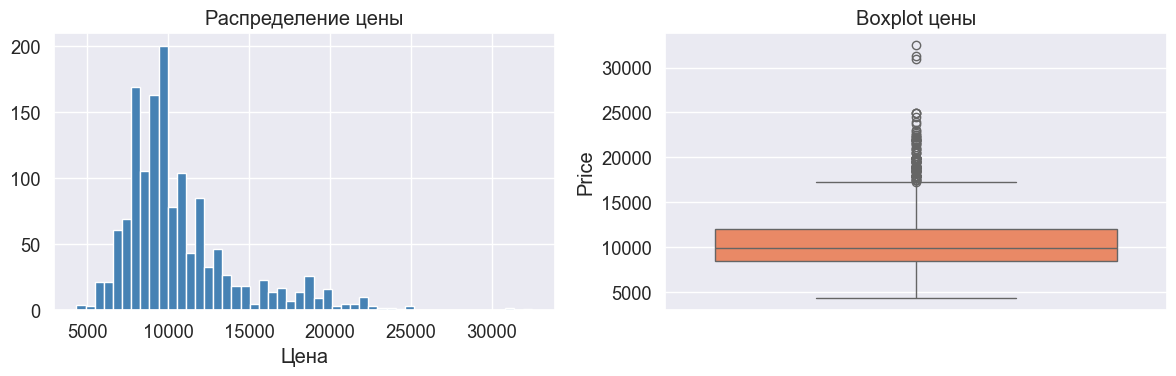

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price'], bins=50, color='steelblue')
axes[0].set_title('Распределение цены')
axes[0].set_xlabel('Цена')

sns.boxplot(y=df['Price'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot цены')

plt.tight_layout()
plt.show()

Большинство цен в промежутке 7000-15000 и длинные хвост вправо

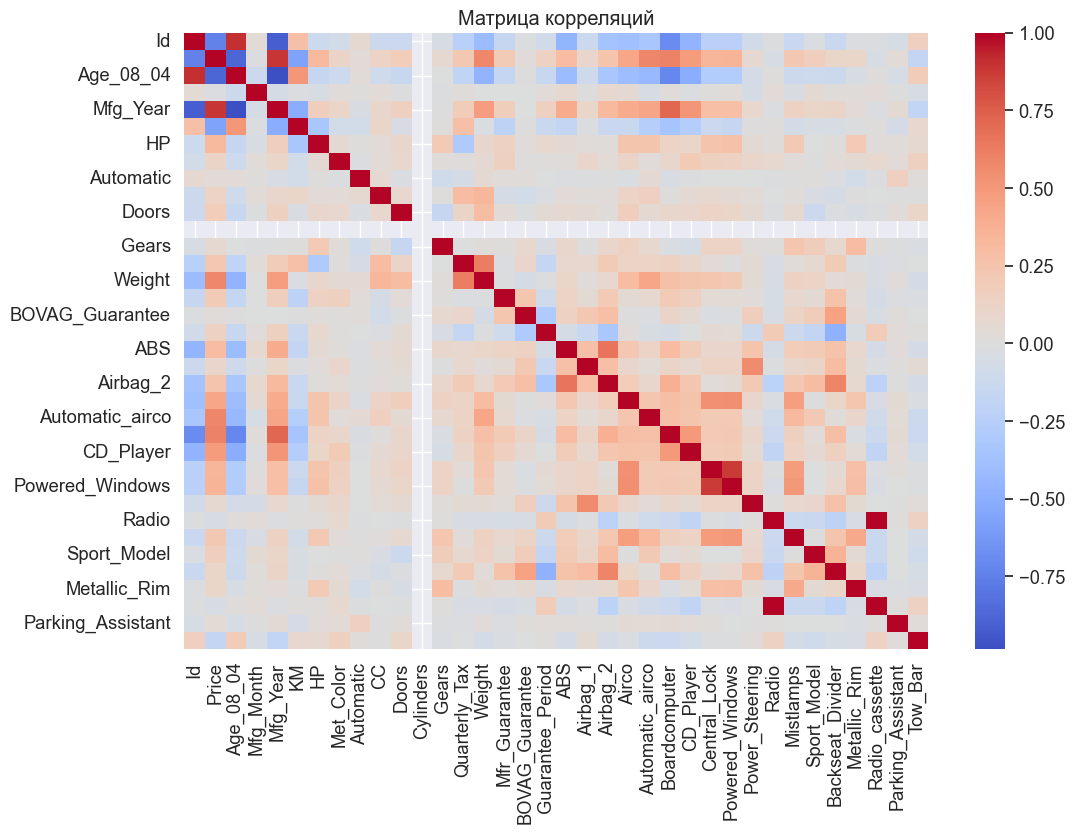

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

In [8]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar             -0.172369
KM                  -0.569960
Id        

In [9]:
df['Cylinders'].value_counts()

Cylinders
4    1436
Name: count, dtype: int64

### Удаляем ненужные столбцы:
1. Id, Model - не несут полезной информации
2. Cylinders - одно и то же значение
3. Mfg_Year — дублирует Age_08_04
4. Mfg_Month, Radio, BOVAG_Guarantee, Gears, Power_Steering - слабая корреляция с ценой

In [10]:
df = df.drop(columns=['Id', 'Model', 'Cylinders', 'Mfg_Year', 'Mfg_Month', 'Radio', 'BOVAG_Guarantee', 'Gears', 'Power_Steering'])

Делаем One-Hot Encoding категориальных признаков

In [11]:
df = pd.get_dummies(df, columns=['Fuel_Type', 'Color'], drop_first=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Price              1436 non-null   int64
 1   Age_08_04          1436 non-null   int64
 2   KM                 1436 non-null   int64
 3   HP                 1436 non-null   int64
 4   Met_Color          1436 non-null   int64
 5   Automatic          1436 non-null   int64
 6   CC                 1436 non-null   int64
 7   Doors              1436 non-null   int64
 8   Quarterly_Tax      1436 non-null   int64
 9   Weight             1436 non-null   int64
 10  Mfr_Guarantee      1436 non-null   int64
 11  Guarantee_Period   1436 non-null   int64
 12  ABS                1436 non-null   int64
 13  Airbag_1           1436 non-null   int64
 14  Airbag_2           1436 non-null   int64
 15  Airco              1436 non-null   int64
 16  Automatic_airco    1436 non-null   int64
 17  Boardcomputer      1436 n

In [13]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Price'] >= Q1 - 1.5 * IQR) & (df['Price'] <= Q3 + 1.5 * IQR)]
df.shape

(1326, 39)

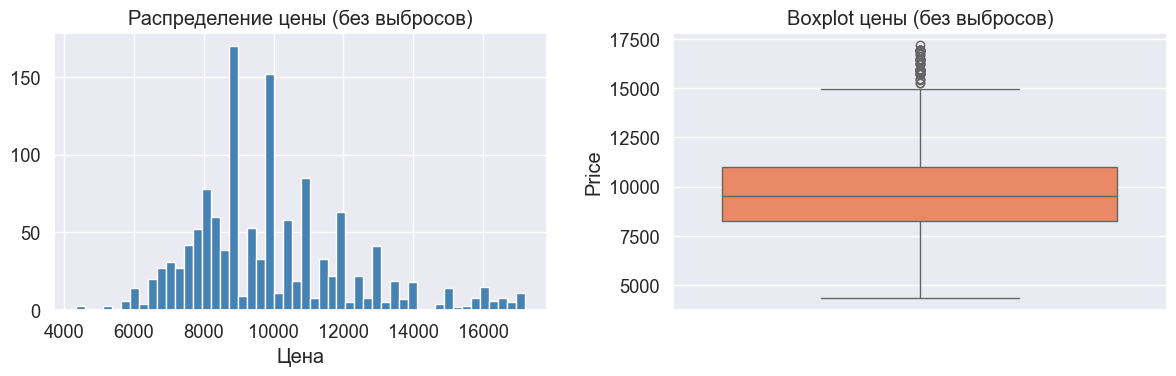

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price'], bins=50, color='steelblue')
axes[0].set_title('Распределение цены (без выбросов)')
axes[0].set_xlabel('Цена')

sns.boxplot(y=df['Price'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot цены (без выбросов)')

plt.tight_layout()
plt.show()

### Feature engineering

In [14]:
df['Age_KM'] = df['Age_08_04'] * df['KM']

<class 'pandas.DataFrame'>
Index: 1326 entries, 0 to 1435
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Price              1326 non-null   int64
 1   Age_08_04          1326 non-null   int64
 2   KM                 1326 non-null   int64
 3   HP                 1326 non-null   int64
 4   Met_Color          1326 non-null   int64
 5   Automatic          1326 non-null   int64
 6   CC                 1326 non-null   int64
 7   Doors              1326 non-null   int64
 8   Quarterly_Tax      1326 non-null   int64
 9   Weight             1326 non-null   int64
 10  Mfr_Guarantee      1326 non-null   int64
 11  Guarantee_Period   1326 non-null   int64
 12  ABS                1326 non-null   int64
 13  Airbag_1           1326 non-null   int64
 14  Airbag_2           1326 non-null   int64
 15  Airco              1326 non-null   int64
 16  Automatic_airco    1326 non-null   int64
 17  Boardcomputer      1326 non-nu

## Разделение на train/test и обучение

### sdfjksdf

In [17]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'{name}: RMSE={rmse:.0f}, MAE={mae:.0f}, R²={r2:.3f}')

LinearRegression: RMSE=1004, MAE=803, R²=0.823
Ridge: RMSE=1000, MAE=802, R²=0.825
Lasso: RMSE=1000, MAE=801, R²=0.825


In [22]:
params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(Ridge(), params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

lasso_grid = GridSearchCV(Lasso(max_iter=10000), params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

print('Ridge лучший alpha:', ridge_grid.best_params_, '| R²:', round(ridge_grid.best_score_, 3))
print('Lasso лучший alpha:', lasso_grid.best_params_, '| R²:', round(lasso_grid.best_score_, 3))

Ridge лучший alpha: {'alpha': 10} | R²: 0.793
Lasso лучший alpha: {'alpha': 10} | R²: 0.8


Оценка упала, но она более правдивая, сделанная с кросс-валидацией

In [23]:
best_models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Lasso (alpha=10)': Lasso(alpha=10, max_iter=10000)
}

for name, model in best_models.items():
    model.fit(X_train_scaled, y_train)
    
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2 = r2_score(y_test, model.predict(X_test_scaled))
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))
    
    print(f'{name}: Train R²={train_r2:.3f} | Test R²={test_r2:.3f} | RMSE={rmse:.0f}')

LinearRegression: Train R²=0.831 | Test R²=0.823 | RMSE=1004
Ridge (alpha=10): Train R²=0.830 | Test R²=0.828 | RMSE=991
Lasso (alpha=10): Train R²=0.828 | Test R²=0.829 | RMSE=988


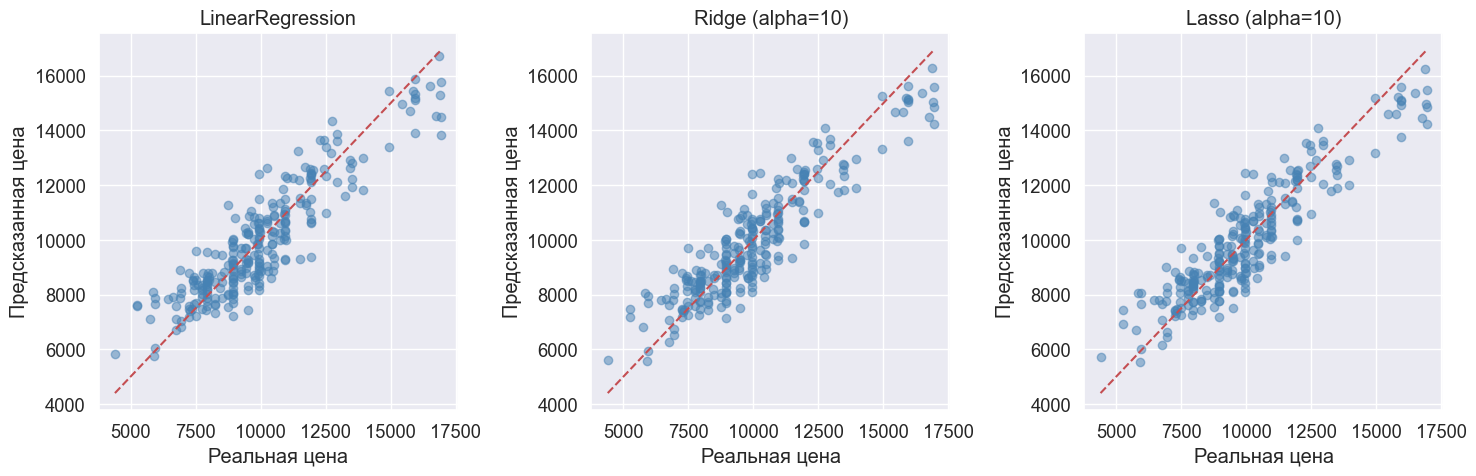

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test_scaled)
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Реальная цена')
    ax.set_ylabel('Предсказанная цена')
    ax.set_title(name)

plt.tight_layout()
plt.show()